In [ ]:
import logging
import os
import pickle
import random
import sys
from os.path import join

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# from hyperopt import fmin, tpe, hp, Trials, rand
import xgboost as xgb
from sklearn.metrics import matthews_corrcoef, roc_auc_score
from sklearn.model_selection import KFold

sys.path.append("./additional_code")
# from data_preprocessing import *
CURRENT_DIR = os.getcwd()
print(CURRENT_DIR)
our_data = CURRENT_DIR + "/../data/our_data/"

/home/hanxd/Repositories/ESP/our_codes


In [ ]:
df = pd.read_pickle(
    join(CURRENT_DIR, "..", "data", "our_data", "p450plant_deletedata.pkl")
)

In [ ]:
speciesdata = pd.read_csv(our_data + "species_ligand.txt", sep="\t", header=0)
deletedata = speciesdata[speciesdata["species"] == "Arabidopsis thaliana"]

In [ ]:
df_box = df[df["substrate"].isin(deletedata["substrate"])]

In [ ]:
filtered_rows = df[(df["Binding"] == 1) & df["enzyme"].isin(deletedata["P450 name"])]

In [ ]:
print(filtered_rows["scores"].tolist())

[0.06856781989336014, 0.022972794249653816, 0.6984798312187195, 0.1014571338891983, 0.49264469742774963, 0.9294983148574829, 0.4071999490261078, 0.7276055216789246, 0.27978628873825073, 0.10943607985973358, 0.6764981150627136, 0.8263384699821472, 0.4505719542503357, 0.551544189453125, 0.1738208681344986, 0.026743020862340927, 0.3043675720691681, 0.9615787267684937, 0.9136207699775696, 0.9307441115379333, 0.7549346685409546, 0.6662400960922241, 0.8827050924301147, 0.16582630574703217, 0.9948040843009949, 0.7470122575759888, 0.8076126575469971, 0.11053790152072906, 0.757938027381897, 0.6162084341049194]


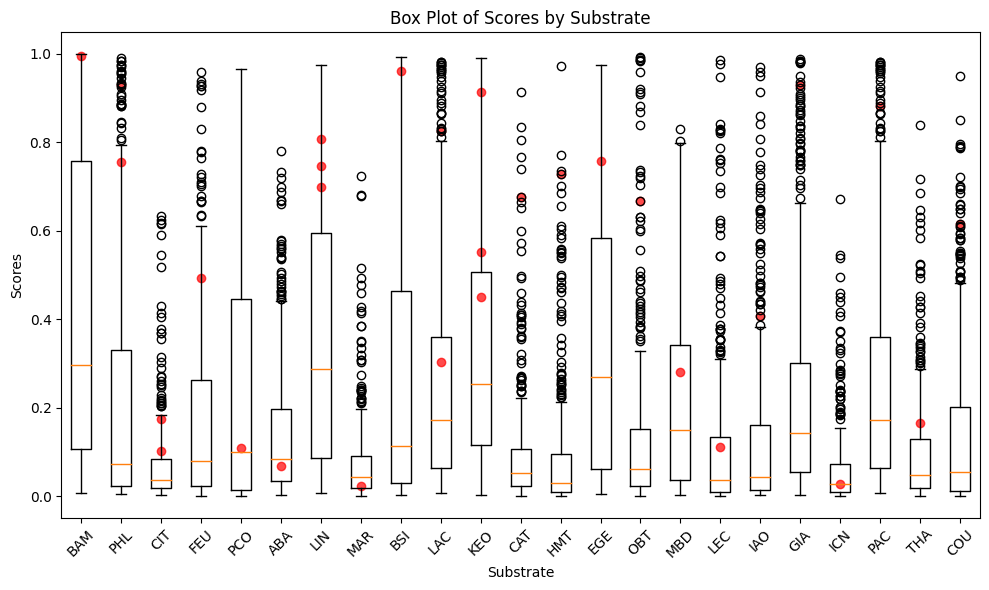

In [ ]:
substrates = df_box["substrate"].unique().tolist()
data_to_plot = [
    df_box[df_box["substrate"] == substrate]["scores"] for substrate in substrates
]


plt.figure(figsize=(10, 6))
box = plt.boxplot(data_to_plot, positions=range(1, len(substrates) + 1))

plt.xticks(range(1, len(substrates) + 1), substrates, rotation=45)

plt.xlabel("Substrate")
plt.ylabel("Scores")
plt.title("Box Plot of Scores by Substrate")

for i, substrate in enumerate(substrates, start=1):
    substrate_scores = filtered_rows[filtered_rows["substrate"] == substrate]["scores"]
    x_coords = [i] * len(substrate_scores)
    plt.scatter(x_coords, substrate_scores, color="red", alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
filtered_rows[filtered_rows["substrate"] == "LAC"]

,enzyme,substrate,Binding,ESM1b,ECFP,scores
35393,CYP86C3,LAC,1.0,"[-0.11193066090345383, 0.11557075381278992, 0....",0000000000000000000000000000000001000000000000...,0.826338
56141,CYP703A2,LAC,1.0,"[0.0037817787379026413, 0.11447639018297195, 0...",0000000000000000000000000000000001000000000000...,0.304368
